In [ ]:
# =============================
# User Configuration
# =============================

CSV_PATH = "./grid_search_20251228_192100_results.csv"

PRIMARY_METRIC = "Recall@10"

# 시각화할 하이퍼파라미터 2개
PARAM_X = "alpha"
PARAM_Y = "within_page_weight"

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [118]:
df = pd.read_csv(CSV_PATH)

print("Rows:", len(df))
df.head()

Rows: 125


,Recall@10,NDCG@10,Precision@10,HitRate@10,model,reg_weight,alpha,page_threshold,cross_page_tau,within_page_weight
0,0.193355,0.230136,0.193355,0.859885,SessionWeightedEASE,4800.0,45,4,400.0,0.3
1,0.193441,0.230193,0.193441,0.859917,SessionWeightedEASE,4800.0,47,4,400.0,0.3
2,0.193460,0.230195,0.193460,0.859758,SessionWeightedEASE,4800.0,49,4,400.0,0.3
3,0.193460,0.230123,0.193460,0.859821,SessionWeightedEASE,4800.0,51,4,400.0,0.3
4,0.193438,0.230063,0.193438,0.859630,SessionWeightedEASE,4800.0,53,4,400.0,0.3


In [119]:
best_row = df.loc[df[PRIMARY_METRIC].idxmax()]
best_row

Recall@10                        0.193555
NDCG@10                          0.230284
Precision@10                     0.193555
HitRate@10                       0.859439
model                 SessionWeightedEASE
reg_weight                         4800.0
alpha                                  51
page_threshold                          4
cross_page_tau                      550.0
within_page_weight                    0.3
Name: 18, dtype: object

In [120]:
metric_cols = ["Recall@10", "NDCG@10", "Precision@10", "HitRate@10"]
param_cols = [c for c in df.columns if c not in metric_cols]

fixed_params = {
    p: best_row[p]
    for p in param_cols
    if p not in [PARAM_X, PARAM_Y]
}

for k, v in fixed_params.items():
    print(f"{k}: {v}")

model: SessionWeightedEASE
reg_weight: 4800.0
page_threshold: 4
cross_page_tau: 550.0


In [121]:
filtered = df.copy()

for p, v in fixed_params.items():
    filtered = filtered[filtered[p] == v]

print("Filtered rows:", len(filtered))
filtered.head()

Filtered rows: 25


,Recall@10,NDCG@10,Precision@10,HitRate@10,model,reg_weight,alpha,page_threshold,cross_page_tau,within_page_weight
15,0.193431,0.230248,0.193431,0.859853,SessionWeightedEASE,4800.0,45,4,550.0,0.3
16,0.193460,0.230238,0.193460,0.859726,SessionWeightedEASE,4800.0,47,4,550.0,0.3
17,0.193520,0.230299,0.193520,0.859630,SessionWeightedEASE,4800.0,49,4,550.0,0.3
18,0.193555,0.230284,0.193555,0.859439,SessionWeightedEASE,4800.0,51,4,550.0,0.3
19,0.193450,0.230181,0.193450,0.859503,SessionWeightedEASE,4800.0,53,4,550.0,0.3


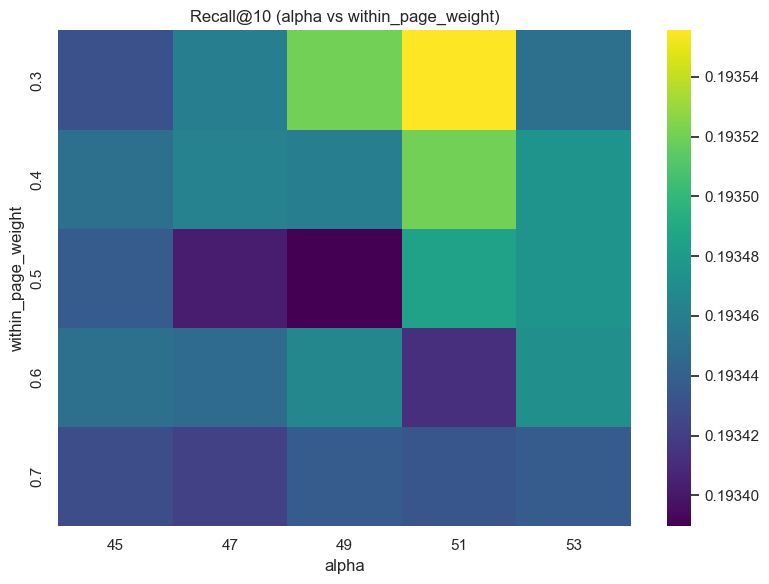

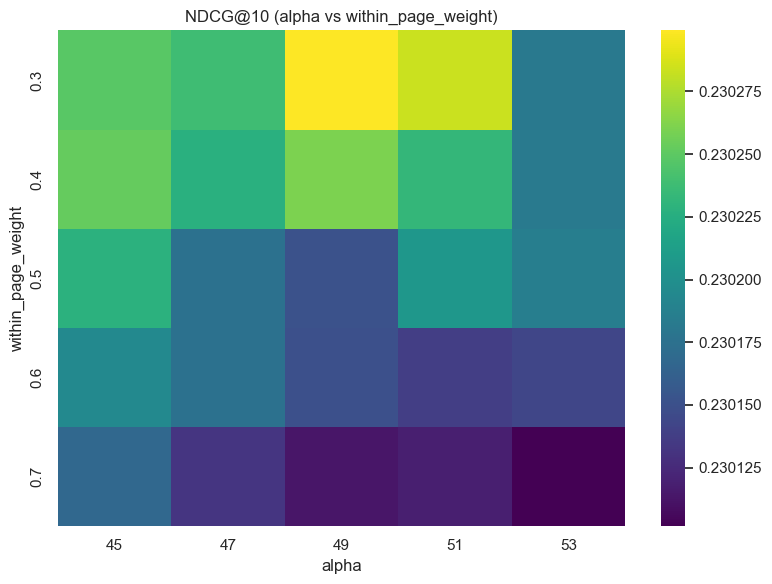

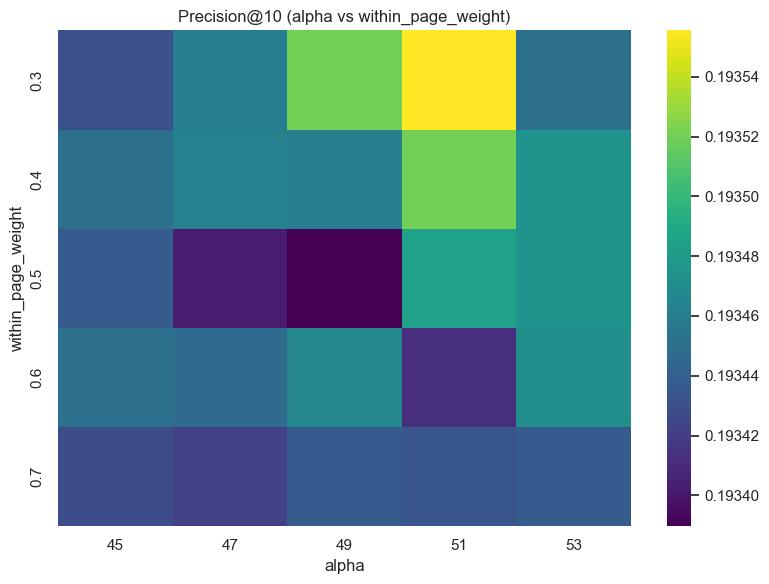

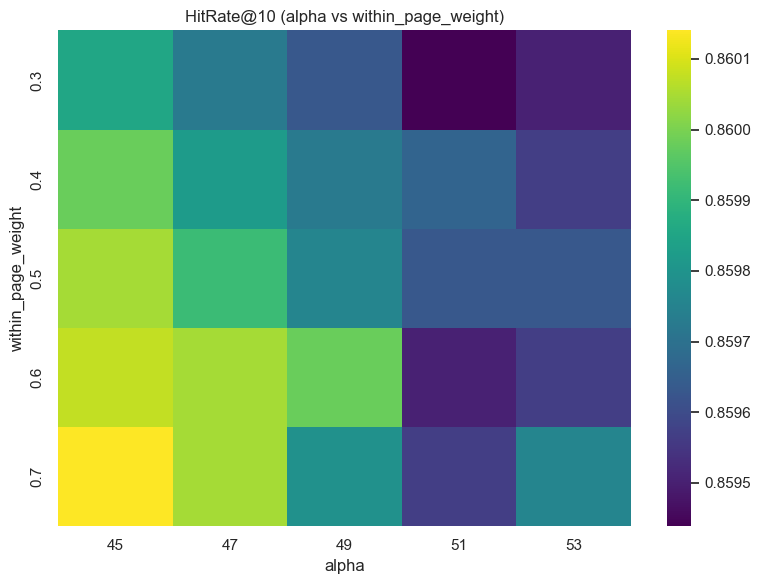

In [122]:
metrics = ["Recall@10", "NDCG@10", "Precision@10", "HitRate@10"]

for metric in metrics:
    pivot = filtered.pivot(
        index=PARAM_Y,
        columns=PARAM_X,
        values=metric
    )

    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot, cmap="viridis", annot=False)
    plt.title(f"{metric} ({PARAM_X} vs {PARAM_Y})")
    plt.xlabel(PARAM_X)
    plt.ylabel(PARAM_Y)
    plt.tight_layout()
    plt.show()

In [123]:
summary_cols = [PARAM_X, PARAM_Y] + metrics

filtered[summary_cols] \
    .sort_values(PRIMARY_METRIC, ascending=False) \
    .head(10)

,alpha,within_page_weight,Recall@10,NDCG@10,Precision@10,HitRate@10
18,51,0.3,0.193555,0.230284,0.193555,0.859439
43,51,0.4,0.193520,0.230233,0.193520,0.859662
17,49,0.3,0.193520,0.230299,0.193520,0.859630
68,51,0.5,0.193485,0.230206,0.193485,0.859630
44,53,0.4,0.193476,0.230182,0.193476,0.859566
69,53,0.5,0.193476,0.230185,0.193476,0.859630
94,53,0.6,0.193473,0.230143,0.193473,0.859566
92,49,0.6,0.193466,0.230150,0.193466,0.859981
41,47,0.4,0.193463,0.230227,0.193463,0.859821
42,49,0.4,0.193460,0.230260,0.193460,0.859726
